# **FinTech Transaction Risk & Explainable Fraud Engine**

**Team:** ModelMates

**Team Members:**
- Chanuth Dewhan
- Praveen Rusiru

**Date:** September 2026

---

## **Introduction**

This notebook outlines the initial data processing and exploratory data analysis (EDA) for the FraudGuard Machine Learning Service.

The goal is to analyze synthetic mobile money transaction logs (PaySim) to identify patterns of fraudulent behavior. The analysis focuses on handling extreme class imbalance, engineering behavioral features, and preparing the dataset for a highly interpretable XGBoost model using SHAP to ensure transparent risk scoring.

In [2]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## **Phase 1: Data Ingestion & Inspection**

Load the raw PaySim financial logs and perform initial structural checks.

**Approach:**
- Ingest `PS_20174392719_1491204439457_log.csv` using `pandas`
- Conduct statistical audit to understand dimensions, missing values, and identify structural anomalies (such as naming conventions).

In [3]:
# Load data
df = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv')

print(f"Financial Transaction Logs Shape: {df.shape}")

Financial Transaction Logs Shape: (6362620, 11)


### **1.1 Initial Data Audit**

Inspect data structure, memory usage and data types to identify potential quality issues early.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


The dataset contains over 6.36 million rows and 11 columns. `.info()` shows no immediate null values. However, looking at the column names, there is inconsistent casing (e.g., `oldbalanceOrg` vs `newbalanceOrig` vs `oldbalanceDest`).

In [5]:
# sample data
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.640,C1231006815,170136.000,160296.360,M1979787155,0.000,0.000,0,0
1,1,PAYMENT,1864.280,C1666544295,21249.000,19384.720,M2044282225,0.000,0.000,0,0
2,1,TRANSFER,181.000,C1305486145,181.000,0.000,C553264065,0.000,0.000,1,0
3,1,CASH_OUT,181.000,C840083671,181.000,0.000,C38997010,21182.000,0.000,1,0
4,1,PAYMENT,11668.140,C2048537720,41554.000,29885.860,M1230701703,0.000,0.000,0,0


The preview confirms the structure. Transactions are mapped by hourly `step` increments. The inconsistent column naming observed in `.info()` should be standardized immediately to camelCase so it seamlessly matches the downstream TypeScript interfaces in the Express backend.

In [6]:
# Standardize column naming conventions for backend compatibility
df = df.rename(columns={
    "oldbalanceOrg": "oldBalanceOrg",
    "newbalanceOrig": "newBalanceOrg",
    "oldbalanceDest": "oldBalanceDest",
    "newbalanceDest": "newBalanceDest",
})

# Verify updated columns
print("Updated Columns:")
df.columns.tolist()

Updated Columns:


['step',
 'type',
 'amount',
 'nameOrig',
 'oldBalanceOrg',
 'newBalanceOrg',
 'nameDest',
 'oldBalanceDest',
 'newBalanceDest',
 'isFraud',
 'isFlaggedFraud']

### **1.2 Data Quality & Integrity Checks**

Before proceeding to feature engineering and modeling, we must verify the dataset for missing values and duplicated rows. Data leakage from duplicates or pipeline failures from unexpected nulls are common pitfalls in production ML systems.

In [7]:
# Check for missing/null values across all columns
missing_values = df.isnull().sum()

print("--- Missing Values Report ---")
if missing_values.sum() == 0:
    print("No missing values found. Dataset is complete.\n")
else:
    print(missing_values[missing_values > 0])
    print("\n")

# Check for duplicate transactions
duplicate_count = df.duplicated().sum()
print(f"--- Duplicate Records Report ---")
print(f"Duplicate rows found: {duplicate_count}")

--- Missing Values Report ---
No missing values found. Dataset is complete.

--- Duplicate Records Report ---
Duplicate rows found: 0


checked for missing values and duplicates, found none. dataset is synthetic and pre-cleaned so this isn't surprising, but want to confirm document data quality explicitly so this check still matters even though the result is "nothing to fix.

### **1.3 Target Variable Distribution (The Class Imbalance Problem)**

In financial fraud detection, fraudulent transactions represent a microscopic fraction of overall volume. We must quantify this to determine our baseline evaluation metrics. If the fraud rate is excessively low, standard evaluation metrics like "Accuracy" become dangerously misleading.

--- Target Variable Distribution (isFraud) ---
isFraud
0    6354407
1       8213

Exact Fraud Rate: 0.1291%
Baseline 'Predict All Zeroes' Accuracy: 99.87%


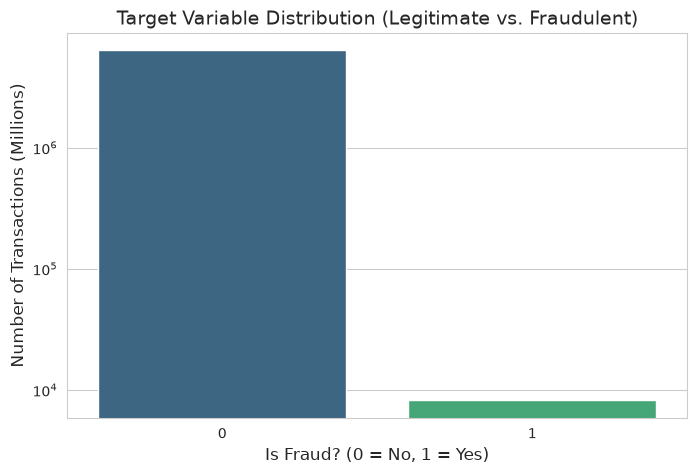

In [8]:
# Calculate the exact distribution of the target variable
fraud_counts = df["isFraud"].value_counts()
fraud_rate = df["isFraud"].mean() * 100

# Calculate the baseline accuracy if a model just guessed "Not Fraud" every time
baseline_accuracy = 100 - fraud_rate

print("--- Target Variable Distribution (isFraud) ---")
print(fraud_counts.to_string())
print(f"\nExact Fraud Rate: {fraud_rate:.4f}%")
print(f"Baseline 'Predict All Zeroes' Accuracy: {baseline_accuracy:.2f}%")

# Visualize the imbalance
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='isFraud', data=df, hue='isFraud', palette='viridis', legend=False)
plt.title("Target Variable Distribution (Legitimate vs. Fraudulent)", fontsize=14)
plt.xlabel("Is Fraud? (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Number of Transactions (Millions)", fontsize=12)
plt.yscale('log') # Use logarithmic scale to make the minority class visible
plt.show()

### **1.4 Fraud Distribution by Transaction Type**

PaySim categorizes transactions into five types: `CASH_IN`, `CASH_OUT`, `DEBIT`, `PAYMENT`, and `TRANSFER`. 

We need to analyze how fraudulent activities are distributed across these channels. Identifying specific vulnerable transaction types allows us to focus our feature engineering efforts on the areas of highest risk.

In [9]:
# Group by transaction type and calculate fraud statistics
fraud_by_type = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean']).reset_index()
fraud_by_type.columns = ['Transaction Type', 'Total Transactions', 'Fraudulent Transactions', 'Fraud Rate']

# Convert the mean to a percentage for readability
fraud_by_type['Fraud Rate'] = fraud_by_type['Fraud Rate'] * 100

# Sort by Fraud Rate descending
fraud_by_type = fraud_by_type.sort_values(by='Fraud Rate', ascending=False)

print("--- Fraud Statistics by Transaction Type ---")
print(fraud_by_type.to_string(index=False))

--- Fraud Statistics by Transaction Type ---
Transaction Type  Total Transactions  Fraudulent Transactions  Fraud Rate
        TRANSFER              532909                     4097       0.769
        CASH_OUT             2237500                     4116       0.184
         CASH_IN             1399284                        0       0.000
           DEBIT               41432                        0       0.000
         PAYMENT             2151495                        0       0.000


**Key Insight:** Fraud in this dataset is highly concentrated. It occurs **exclusively** within two transaction types: `TRANSFER` and `CASH_OUT`. 

This perfectly aligns with real-world mobile money fraud patterns where an attacker first transfers funds to a compromised account (`TRANSFER`), and then immediately withdraws the funds to avoid reversal (`CASH_OUT`). 

**Architectural Decision:** During the feature engineering phase, we will apply One-Hot Encoding to the `type` column. The model will likely learn to assign significantly higher baseline risk to `TRANSFER` and `CASH_OUT` events.

### **1.5 Transaction Amount Distribution & Skewness**

Financial transaction amounts are notorious for being heavily right-skewed (millions of small transactions and a few massive, multi-million dollar transactions). Tree-based models like XGBoost handle unscaled data reasonably well, but extreme outliers can still distort splits and affect SHAP value interpretability.

We will visualize the raw `amount` alongside a logarithmic transformation (`log1p`) to evaluate variance stabilization.

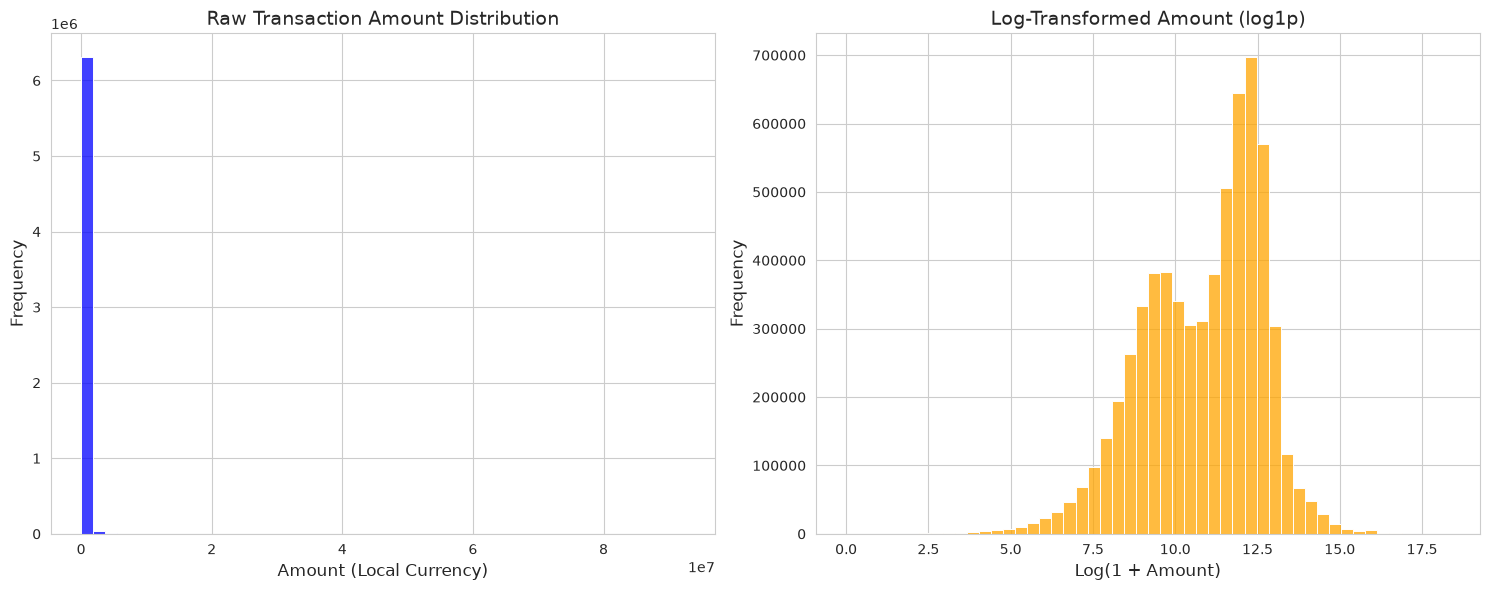

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Raw Transaction Amount
sns.histplot(df['amount'], bins=50, ax=axes[0], color='blue', kde=False)
axes[0].set_title('Raw Transaction Amount Distribution', fontsize=14)
axes[0].set_xlabel('Amount (Local Currency)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Plot 2: Log-Transformed Transaction Amount
# Using log1p (log(1 + x)) to safely handle zero amounts
sns.histplot(np.log1p(df['amount']), bins=50, ax=axes[1], color='orange', kde=False)
axes[1].set_title('Log-Transformed Amount (log1p)', fontsize=14)
axes[1].set_xlabel('Log(1 + Amount)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

**Key Insight:** The raw `amount` distribution is so severely right-skewed that the histogram appears as a single vertical bar, masking the underlying data structure. Applying the `log1p` transformation reveals a much clearer, multi-modal distribution that stabilizes the variance.

**Architectural Decision:** We will include a `logAmount` feature in our `preprocessing.py` pipeline to ensure the model can meaningfully distinguish between magnitude differences in higher transaction tiers.

### **1.6 Behavioral Fraud Signals: Ledger Discrepancies**

In a perfectly isolated transaction, the arithmetic should perfectly balance: 
`Old Balance - Transaction Amount = New Balance`

We will calculate this mathematical error (`errorBalanceOrig`) and create a boolean flag (`hasBalanceMismatch`) to see how ledger inconsistencies correlate with our `isFraud` target.

In [11]:
# Calculate the ledger mismatch for the origin account
df["errorBalanceOrig"] = df["oldBalanceOrg"] - df["amount"] - df["newBalanceOrg"]

# A mismatch exists if the absolute error is greater than a tiny threshold (e.g., 1) to account for float rounding
df['hasBalanceMismatch'] = (df["errorBalanceOrig"].abs() > 1).astype(int)

# Compare mismatch rates between legitimate and fraudulent transactions
mismatch_rates = df.groupby("isFraud")["hasBalanceMismatch"].mean() * 100

print("--- Percentage of Transactions with Ledger Mismatches ---")
print(f"Legitimate Transactions (isFraud=0): {mismatch_rates[0]:.2f}%")
print(f"Fraudulent Transactions (isFraud=1): {mismatch_rates[1]:.2f}%")

--- Percentage of Transactions with Ledger Mismatches ---
Legitimate Transactions (isFraud=0): 78.70%
Fraudulent Transactions (isFraud=1): 0.55%


**Key Insight:** The result is the exact opposite of what one might initially expect. Legitimate transactions show a balance mismatch 78.70% of the time, while fraudulent transactions show one only 0.55% of the time. In this dataset, fraud is actually *more* arithmetically clean than normal activity.

**Why this happens:** This is a known artifact of how the PaySim simulator generates fraud. The simulator's fraud-injection logic drains the origin account with exact, clean arithmetic. Legitimate transactions in the simulation pick up messier, less perfectly-reconciled balances, likely simulating concurrent ledger activity.

**Architectural Decision:** We will retain `errorBalanceOrig` as an engineered feature because it is highly predictive in this specific dataset. We do not need to manually code the direction of the relationship (low mismatch -> higher risk); our XGBoost model will naturally learn the direction of this split during training.

 ### **1.7 Behavioral Fraud Signals: Account Draining**

A classic cash-out fraud pattern involves compromising an account and immediately transferring exactly 100% of the available funds to a destination account, leaving the origin balance at precisely 0.00. We will flag transactions that exhibit this "drain to zero" behavior.

In [12]:
# Flag transactions where the account was completely drained
# Condition: New balance is exactly 0, AND the starting balance was greater than 0
df["origDrainedToZero"] = ((df["newBalanceOrg"] == 0) & (df["oldBalanceOrg"] > 0)).astype(int)

# Compare drain rates
drain_rates = df.groupby("isFraud")["origDrainedToZero"].mean() * 100

print("--- Percentage of Transactions Draining Account to Zero ---")
print(f"Legitimate Transactions (isFraud=0): {drain_rates[0]:.2f}%")
print(f"Fraudulent Transactions (isFraud=1): {drain_rates[1]:.2f}%")

--- Percentage of Transactions Draining Account to Zero ---
Legitimate Transactions (isFraud=0): 23.80%
Fraudulent Transactions (isFraud=1): 97.55%


## **EDA Conclusion & Feature Strategy**

Based on the exploratory data analysis, the foundation for our Machine Learning pipeline is clear:
1. **Class Imbalance:** Extreme (0.13% fraud). Accuracy is invalid; we will optimize for PR-AUC and use `scale_pos_weight` during XGBoost training.
2. **Target Isolation:** Fraud only occurs in `TRANSFER` and `CASH_OUT` types. We will One-Hot Encode the `type` feature.
3. **Distribution Skew:** Transaction amounts are heavily right-skewed. We will apply a `log1p` transformation to stabilize variance.
4. **Behavioral Features:** Ledger discrepancies (`errorBalanceOrig`) and account draining (`origDrainedToZero`) are both strong predictive signals. Notably, fraud shows lower balance mismatch than legitimate transactions (a PaySim simulation artifact, see 1.6), while account draining shows the expected direction (97.55% of fraud vs. 23.80% of legitimate transactions).

*Next Step: Translating these insights into a reproducible `preprocessing.py` pipeline.*